# Multiscale Energy Systems MILP with Material and Emission Consideration

__author__ = "Rahul Kakodkar, Yilun Lin"
__copyright__ = "Copyright 2023, Multi-parametric Optimization & Control Lab"
__credits__ = ["Rahul Kakodkar", "Yilun Lin", Efstratios N. Pistikopoulos"]
__license__ = "MIT"
__version__ = "1.1.0"
__maintainer__ = "Rahul Kakodkar"
__email__ = "cacodcar@tamu.edu"
__status__ = "Production"


## Problem Statement

The following case study considers three different type of solar photovoltaics, namely Monocrystalline (PV_Mo), Polycrystalline (PV_Po), and Cadmium Telluride (PV_Cd) and  Lithium-ion batteries made of either rock-based lithium (LiI_Ro) or brine-based lithium (LiI_Br).

The goal is to meet a varying demand for power through renewable power generation using the PVs and Lithium-ion batteries for energy storage.

Notably, the different PVs also have different conversion efficiences, as also operational expenditure. Emissions need to be tracked from all components, i.e. resource consumption, materials for establishing processs, emissions from setting up the process. 

Total emissions will atleast include the sum of the emissions from different components (at the network level) and as direct emissions from process (at the scheduling level)

Users are advised caution in terms of assigning the emissions at the appropriate levels and avoiding double account. For example, if providing the global warming potentials (GWP) for each individual material to make up a process, the GWP for processes should only consider the values for construction. Moreover, the direct emissions are considered through the resource balance constraint.

## Nomenclature



*Sets*


$\mathcal{R}$ - set of all resources r

$\mathcal{P}$ - set of all processes p

$\mathcal{T}$ - set of temporal periods t

$\mathcal{B}$ - set of transport modes b

$\mathcal{L}$ - set of locations l

$\mathcal{M}$ - set of materials m

*Subsets*


$\mathcal{R}^{storage}$ - set of resources that can be stored

$\mathcal{R}^{sell}$ - set of resources that can be discharged

$\mathcal{R}^{demand}$ - set of resources that meet  demand

$\mathcal{R}^{cons}$ - set of resources that can be consumed

$\mathcal{R}^{trans}$ - set of resources that can be transported

$\mathcal{P}^{uncertain}$ - set of processes with uncertain capacity

$\mathcal{T}^{net}$ - set of temporal periods t for network level decision making

$\mathcal{T}^{sch}$ - set of temporal periods t for schedule level decision making

*Continuous Variables*


$P_{l,p,t}$ - production level of p $\in$  $\mathcal{P}$ in time period t $\in$ $\mathcal{T}^{sch}$  

$C_{l,r,t}$ - consumption of r $\in$ in $\mathcal{R}^{cons}$ time period t $\in$ $\mathcal{T}^{sch}$ 

$S_{l,r,t}$ - discharge of r $\in$ in $\mathcal{R}^{demand}$ time period t $\in$ $\mathcal{T}^{sch}$ 

$Inv_{l,r,t}$ - inventory level of r $\in$ $\mathcal{R}^{storage}$  in time period t $\in$ $\mathcal{T}^{sch}$

$Cap^S_{l,r,t}$ - installed inventory capacity for resource r $\in$  $\mathcal{R}^{storage}$ in time period t $\in$ $\mathcal{T}^{net}$

$Cap^P_{l,p,t}$ - installed production capacity for process p $\in$ $\mathcal{P}$ in time period t $\in$ $\mathcal{T}^{net}$

$Mat^P_{l,p,m,t}$ - material m $\in$ $\mathcal{M}$ used by process p $\in$ $\mathcal{P}$ in time period t $\in$ $\mathcal{T}^{net}$

$Em^{p/r/m}_{l,p/r/m,t}$ - emission from process/resource/material in time t $\in$ $\mathcal{T}^{net}$


*Binary Variables*

$X^P_{l,p,t}$ - network binary for production process p $\in$ $\mathcal{P}$

$X^S_{l,r,t}$ - network binary for inventory of resource r $\in$  $\mathcal{R}^{storage}$ 

*Parameters*

$Cap^{P-max}_{l,p,t}$ - maximum production capacity of process p $\in$ $\mathcal{P}$ in time t $\in$ $\mathcal{T}^{net}$

$Cap^{S-max}_{l,r,t}$ - maximum inventory capacity for process r $\in$ $\mathcal{R}^{storage}$ in time t $\in$ $\mathcal{T}^{net}$

$Capex_{l,p,t}$ - capital expenditure for process p $\in$ $\mathcal{P}$ in time t $\in$ $\mathcal{T}^{net}$

$Vopex_{l,p,t}$ - variable operational expenditure for process p $\in$ $\mathcal{P}$ in time t $\in$ $\mathcal{T}^{sch}$

$Price_{l,r,t}$ - purchase price for resource r $\in$ $\mathcal{R}^{cons}$ in time t $\in$ $\mathcal{T}^{sch}$

$C^{max}_{l,r,t}$ - maximum consumption availability for resource r $\in$ $\mathcal{R}^{cons}$ in time t $\in$ $\mathcal{T}^{sch}$

$D_{l,r,t}$ - demand for resource r $in$ $\mathcal{R}^{sell}$ in time t $\in$ $\mathcal{T}^{sch}$

$\alpha$ - annualization factor

$Mat^{cons}_{p,m}$ - material m $\in$ $\mathcal{M}$ consumed by process p $\in$ $\mathcal{P}$

$GWP^{p/r/m}_{l,p/r/m,t}$ - global warming indicators for process/resource/material in time t $\in$ $\mathcal{T}^{net}$


## MILP Formulation

Given is a mulit-scale modeling and optimization MILP framework for the simultaneous design and schedule planning of a single location energy system 

\begin{equation}
min \sum_{l \in \mathcal{L}} \Big(\sum_{t \in \mathcal{T}^{net}} \sum_{p \in \mathcal{P}} (\alpha \times Capex_{l,p,t} + Fopex_{l,p,t}) \times Cap^P_{l,p,t} +  \sum_{t \in \mathcal{T}^{sch}} \sum_{r \in \mathcal{R}}  Vopex_{l,r,t} \times P_{l,r,t} 
\end{equation}

\begin{equation*}
+ \sum_{t \in \mathcal{T}^{sch}} \sum_{r \in \mathcal{R}^{cons}} C_{l,r,t} \times Price_{l,r,t} \Big)
\end{equation*}

\begin{equation}
Cap^S_{l,r,t} \leq Cap^{S-max}_{l,r,t} \times X^S_{l,r,t} \hspace{1cm} \forall r \in \mathcal{R}^{storage}, t \in \mathcal{T}^{net}
\end{equation}

\begin{equation}
Cap^P_{l,p,t} \leq Cap^{P-max}_{l,p,t} \times X^P_{l,p,t}  \hspace{1cm} \forall p \in \mathcal{P}, t \in \mathcal{T}^{net}, l \in \mathcal{L}
\end{equation} 

\begin{equation}
P_{l,p,t} \leq Cap^{P}_{l,p,t}  \hspace{1cm} \forall p \in \mathcal{P}, t \in \mathcal{T}^{sch}
\end{equation} 

\begin{equation}
Inv_{l,r,t} \leq Cap^{S}_{l,r,t}  \hspace{1cm} \forall r \in \mathcal{R}^{storage}, t \in \mathcal{T}^{sch}
\end{equation} 


\begin{equation}
- S_{l,r,t} \leq - D_{l,r,t}  \hspace{1cm} \forall r \in \mathcal{R}, t \in \mathcal{T}^{sch}
\end{equation}

\begin{equation}
C_{l,r,t} \leq C^{max}_{l,r,t} \hspace{1cm} \forall r \in \mathcal{R}, t \in \mathcal{T}^{sch}
\end{equation}

\begin{equation}
\sum_{p \in \mathcal{P}} P_{l,p,t} \times \eta(p,r) + C_{l,r,t} +  Inv_{l,r,t-1}=  Inv_{l,r,t} + S_{l,r,t}  
\end{equation}

\begin{equation*}
\forall r \in \mathcal{R}^{cons}, t \in \mathcal{T}^{sch}, l \in \mathcal{L}
\end{equation*}

\begin{equation}
Mat_{l,p,m,t} = Mat^{cons}_{p,m} \times Cap^P_{l,p,t} \hspace{1cm} \forall m \in \mathcal{M}, p \in \mathcal{P}, t \in \mathcal{T}^{net}
\end{equation}

\begin{equation}
Em^{r}_{l,r,t} = GWP^{r}_{l,r,t} \times C_{l,r,t} \hspace{1cm} \forall r \in \mathcal{R}, t \in \mathcal{T}^{sch}
\end{equation}

\begin{equation}
Em^{m}_{l,m,t} = GWP^{m}_{l,m,t} \times \sum_{p \in \mathcal{P}} Mat_{l,p,m,t} \hspace{1cm} \forall p \in \mathcal{P}, t \in \mathcal{T}^{net}
\end{equation}

\begin{equation}
Em^{p}_{l,p,t} = GWP^{p}_{l,p,t} \times prod_{l,p,t} \hspace{1cm} \forall p \in \mathcal{P}, t \in \mathcal{T}^{net}
\end{equation}

\begin{equation}
S_{l,r,t}, C_{l,r,t}, Inv_{l,r,t}, P_{l,p,t}, Cap^P_{l,p,t}, Cap^S_{l,r,t}, Mat_{l,p,m,t}, Em^{p/r/m}_{l,p/r/m,t} \in R_{\geq 0}
\end{equation}



## Import Modules

In [1]:
import sys
sys.path.append('../../src')

In [2]:
import sys
sys.path.append('../src')

In [3]:
import pandas
import numpy
from energiapy.components.temporal_scale import TemporalScale
from energiapy.components.resource import Resource, VaryingResource
from energiapy.components.process import Process, VaryingProcess
from energiapy.components.material import Material
from energiapy.components.location import Location
from energiapy.components.network import Network
from energiapy.components.scenario import Scenario
from energiapy.components.transport import Transport
from energiapy.model.formulate import formulate, Constraints, Objective
from energiapy.utils.nsrdb_utils import fetch_nsrdb_data
from energiapy.plot import plot_results, plot_scenario
from energiapy.plot.plot_results import CostY, CostX
from energiapy.model.solve import solve
from itertools import product


from energiapy.components.result import Result
from itertools import product
from matplotlib import rc
import matplotlib.pyplot as plt
from energiapy.model.solve import solve
from energiapy.plot.plot_results import CostY, CostX
from energiapy.components.location import Location
from energiapy.plot import plot_results, plot_scenario
from energiapy.utils.nsrdb_utils import fetch_nsrdb_data
from energiapy.model.formulate import formulate, Constraints, Objective
from energiapy.model.bounds import CapacityBounds
from energiapy.utils.data_utils import get_data, make_henry_price_df, remove_outliers, load_results

from energiapy.conversion.photovoltaic import solar_power_output
from energiapy.conversion.windmill import wind_power_output
from energiapy.model.constraints.integer_cuts import constraint_block_integer_cut, constraint_block_integer_cut_min
from energiapy.aggregation.reduce_scenario import reduce_scenario, Clustermethod
from energiapy.aggregation.ahc import IncludeAHC



## Data Import

In [4]:
horizon = 1

The following data is needed for the model

- solar and wind profiles : energiapy.fetch_nsrdb_data imports data from the NREL NSRDB database
- power demand : ERCOT for Houston


**Get Weather data (change)**

In [5]:
# def load_data(loc: str, index: list):
#     df = pandas.read_csv(f'./data/{loc}_solar19.csv')
#     df['idx'] = index
#     df = df.set_index('idx')
#     return df
# idx = [(i, j, k) for i, j, k in product(range(1), range(365), range(24))]


In [6]:
# weather_ho = load_data('ho', idx)[['dni']]

Weather in houston

In [7]:
coord = (-17.78, -63.19)
weather_bolivia = pandas.read_csv('./data/weather_bolivia.csv', index_col=0)
weather_bolivia.index = pandas.to_datetime(weather_bolivia.index, utc = True)

Power Demand

In [8]:
df = pandas.read_csv('./data/data_bolivia.csv', index_col=0)

In [9]:

column_list=[df[col].tolist() for col in df.columns]
combined_list= [column_list[i][j] for j in range(365) for i in range(24) ]

In [10]:

df = pandas.DataFrame(combined_list)

def load_data(loc: str, index: list):
    df = pandas.read_csv('./data/data_bolivia.csv', index_col=0)
    df['idx'] = index
    df = df.set_index('idx')
    return df
idx = [(i, j, k) for i, j, k in product(range(1), range(24), range(365))]

demand_bolivia = df

In [11]:
len(column_list)

24

In [12]:
wind_bolivia = wind_power_output(data= weather_bolivia, roughness_length= 0.1, turbine_type= 'V100/1800', hub_height= 92, 
                                 wind_speed_model= 'logarithmic', density_model = 'ideal_gas', temperature_model = 'linear_gradient', 
                                 power_output_model = 'power_coefficient_curve', density_correction = True, obstacle_height = 0, 
                                 observation_height = 10)

solar_bolivia = solar_power_output(data= weather_bolivia, coord=coord, sam = 'cecmod', module_params= 'Canadian_Solar_Inc__CS5P_220M', 
                                   inverter = 'cecinverter', inverter_params= 'ABB__MICRO_0_25_I_OUTD_US_208__208V_', 
                                   temperature_params= 'open_rack_glass_glass', aoi_model= 'no_loss', ac_model= 'sandia', spectral_model= 'no_loss')

In [13]:
	 	 	 	 	 	 	 
ng_price = [1.1902]*31*24 + [1.1981]*28*24 + [1.1829]*31*24 + [1.1893]*30*24 + [1.1961]*31*24 + [1.1929]*30*24 + [1.1941]*31*24 + [1.1993]*31*24 + [1.2144]*30*24 + [1.2373]*31*24 + [1.2358]*30*24 + [1.2249]*31*24

ng_price = pandas.DataFrame(data={'ng': ng_price})
 	 	 	 	 	 	 	 	 	 

In [14]:
solar_bolivia[:24]

,Value
,
1970-01-01 00:00:00.000002022+00:00,0.000000
1970-01-01 00:00:00.000002022+00:00,0.000000
1970-01-01 00:00:00.000002022+00:00,0.000000
1970-01-01 00:00:00.000002022+00:00,0.000000
1970-01-01 00:00:00.000002022+00:00,0.000000
1970-01-01 00:00:00.000002022+00:00,0.000000
1970-01-01 00:00:00.000002022+00:00,2.073616
1970-01-01 00:00:00.000002022+00:00,8.045836
1970-01-01 00:00:00.000002022+00:00,8.933880


**No solar for first 13 hours with non-zero demand fix**

In [15]:
# for i in range(13):
#     weather_ho['dni'][0, 0, i] = 0.5

**Demand data for Houston (ERCOT for COAST region)**

## Define temporal scale


The variabilities of energy systems are best captured over a discretized spatio-temporal scale. In energiapy, the first declaration is the temporal scale. 

For e.g.: Here we declare three temporal scales at different levels from right to left. The interpretation of these scales is merely symentic. Scales can be declared as the problem demands.
- 0, annual, with 1 discretization
- 1, daily with 365 discretization
- 2, hourly with 24 discretization

In essence, we are creating a temporal scale of 8760 points.

In [16]:
scales = TemporalScale(discretization_list=[1, 365, 24])
# scales = TemporalScale(discretization_list=[horizon, 365, 24])

## Declare resources

Resources can be consumed, produced, stored, discharged (or sold).

Power demand follows a varying deterministic demand

In [17]:
bigM = 10000
smallM = 0.0000000001

In [18]:
Solar = Resource(name='Solar', cons_max=bigM, price=0, basis='MW', label='Solar Power')

Wind = Resource(name='Wind', cons_max=bigM, price=0, basis='MW', label='Wind Power')

Water = Resource(name='Water', cons_max=bigM, price=0, basis='ton', label='Hydro Power')

Biomass = Resource(name='Biomass', price=43.3, cons_max=bigM, basis='ton', label='Biomass Power')

NG = Resource(name='Natural Gas', price=128.81, basis='ton',
                     cons_max=bigM, label='Natural Gas', gwp = 1249.181, varying = [VaryingResource.DETERMINISTIC_PRICE])

Oil = Resource(name='Oil', price=572.166, basis='ton',
                     cons_max=bigM, label='Oil', gwp = 1558.187)

Power = Resource(name='Power', basis='MW', label='Power generated', demand = True, varying=[VaryingResource.DETERMINISTIC_DEMAND])

GridPower = Resource(name='GridPower', basis='MW',
                     cons_max=bigM, label='Power bought', price=149, gwp=410)

LiI_Power = Resource(name='LiIPower', basis='MW',
                     store_max=bigM, label='Power bought')

CO2_Vent = Resource(name='CO2_Vent', sell=True, basis='tons', label='Carbon dioxide', gwp = 1000)


## Declare Processes

In [19]:
#STORAGE PROCESSES

#LiI = Process(name='LiI', conversion={Power: -1, LiI_Power: 1}, capex=1938204, fopex=444247, vopex=0,
#               store_min=smallM, prod_max=bigM, prod_min=smallM, label='Lithium-ion battery', basis='MW')
#https://atb.nrel.gov/electricity/2023/utility-scale_battery_storage#

#LiI_discharge = Process(name='LiI_discharge', conversion={Power: 1, LiI_Power: -1}, capex=0,
#                       fopex=0, vopex=0, prod_max=bigM, prod_min=smallM,  label='Lithium-ion battery (d)', basis='MW')

PV = Process(name='Solar PV', conversion={Solar: -1, Power: 1, CO2_Vent:0.043}, capex=1729631.94*0.9, fopex=21861, vopex=0, land = 10800/1800,
               prod_min=smallM, prod_max=165.0, varying=[VaryingProcess.DETERMINISTIC_CAPACITY], label='Solar PV', basis='MW', block='power')
#Capex: https://www.cne.cl/wp-content/uploads/2021/06/03-ITP-Estudio-de-la-Unidad-de-Punta_VF.pdf
#Vopex: Email they provided

# WIND OPTIONS
WF = Process(name='WF', conversion={Wind: -1, Power: 1, CO2_Vent:0.013}, 
            capex=2046587.30*0.9, fopex=32060, vopex=0, land = 10800/1800,
             prod_max=135.0, prod_min=smallM, label='Wind mill array', block='power', varying=[VaryingProcess.DETERMINISTIC_CAPACITY], basis='MW')
#Capex: https://www.cne.cl/wp-content/uploads/2021/06/03-ITP-Estudio-de-la-Unidad-de-Punta_VF.pdf
#Vopex: Email they provided

Hydro_prod = Process(name='Hydro production', conversion={Water: -1, Power: 1, CO2_Vent:0.021}, 
             capex=2058468.56*0.9, fopex=92000, vopex=0, land = 10800/1800,
             prod_max=734.0, prod_min=smallM, label='Hydroproduction', block='power', basis='MW')
#734
#Capex: https://www.statista.com/statistics/243725/capital-costs-of-a-typical-us-hydrothermal-power-plant/
#Vopex: Email they provided

#Limit this Capacities
Biomass_prod = Process(name='Biomass production', conversion={Biomass: -1.25, Power: 1, CO2_Vent:0.052}, 
             capex=1916666.67*0.9, fopex=19813, vopex=0, land = 10800/1800,
             prod_max=bigM, prod_min=127.0, label='Biomass production', block='power', basis='MW')

# NG_prod = Process(name='NG production', conversion={NG: -0.161, Power: 1, CO2_Vent:0.486}, 
#              capex=1175000, fopex=16300, vopex=0, land = 10800/1800,
#              prod_max=2.577*0.3, prod_min=smallM, label='NG production', block='power', basis='MW')


NG_prod = Process(name='NG production', conversion={NG: -0.161, Power: 1, CO2_Vent:0.486}, 
              capex=1175000, fopex=16300, vopex=0, land = 10800/1800,
             prod_max=smallM, prod_min=smallM, label='NG production', block='power', basis='MW')

#2348.67226, 2577

Oil_prod = Process(name= 'Oil production', conversion={Oil: -0.2517, Power: 1, CO2_Vent:0.840}, 
             capex=1226000, fopex=13100, vopex=0, land = 10800/1800,
             prod_max=84, prod_min=smallM, label='Oil production', block='power', basis='MW')

# # Grid purchase and demand sectors
# Grid = Process(name='Grid', conversion={GridPower: -1, Power: 1, CO2_Vent:0.471}, capex=smallM,
#                fopex=smallM, vopex=smallM, prod_min=smallM, prod_max=bigM, label='Grid', basis='MW')

## Declare Location

In [20]:
process_set = {NG_prod, Oil_prod, PV, WF, Hydro_prod, Biomass_prod}

In [21]:
# houston = Location(name='HO', processes=process_set, capacity_factor={PV: weather_ho, 
#                                                                       WF: wind_houston[:8760*horizon]}, demand_factor={Power: demand_bolivia},
#                    scales=scales, label='Houston', demand_scale_level=2, capacity_scale_level=2, price_scale_level=2)

In [22]:
bolivia = Location(name='BO', processes=process_set, capacity_factor={PV: solar_bolivia, 
                                                                      WF: wind_bolivia[:8760*horizon]}, demand_factor={Power: demand_bolivia}, price_factor = {NG: ng_price},
                   scales=scales, label='Bolivia', demand_scale_level=2, capacity_scale_level=2, price_scale_level=2)

## Declare Scenario

In [23]:

scenario = Scenario(name='scenario_full', network=bolivia, scales=scales,  expenditure_scale_level=0, scheduling_scale_level=2,
                    network_scale_level=0, demand_scale_level=2, capacity_scale_level = 2, purchase_scale_level = 2,  label='full_case', demand={bolivia:{Power:demand_bolivia.max()[0]}})

# https://www.thenationalnews.com/opinion/comment/2022/03/22/world-water-day-a-chance-for-the-uae-to-re-think-our-use-of-resources/#:~:text=Newer%20sustainable%20desalination%20methods%20are,between%209%20and%2010%20BCM.
# 4.5 BILLION CUBIC METERS OF WATER TO ADD BY 2030 (DOUBLE CURRENT PRODUCTION 4.5 TO 9-10 BCM)

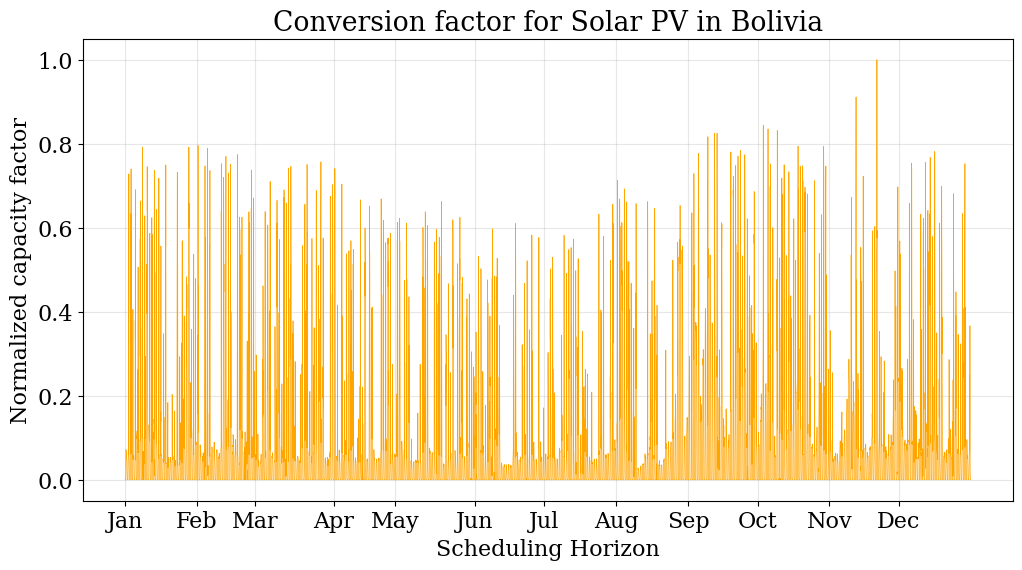

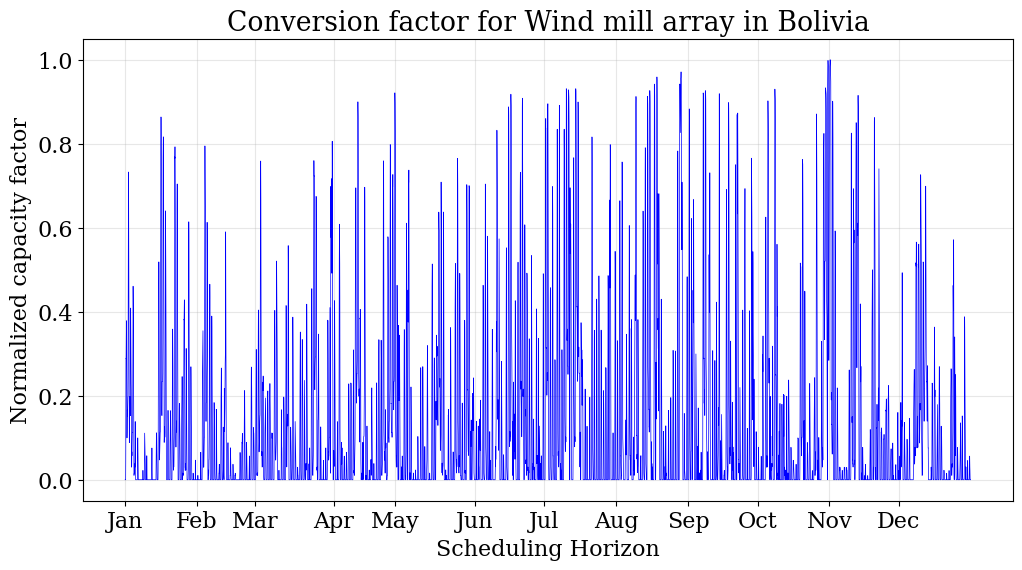

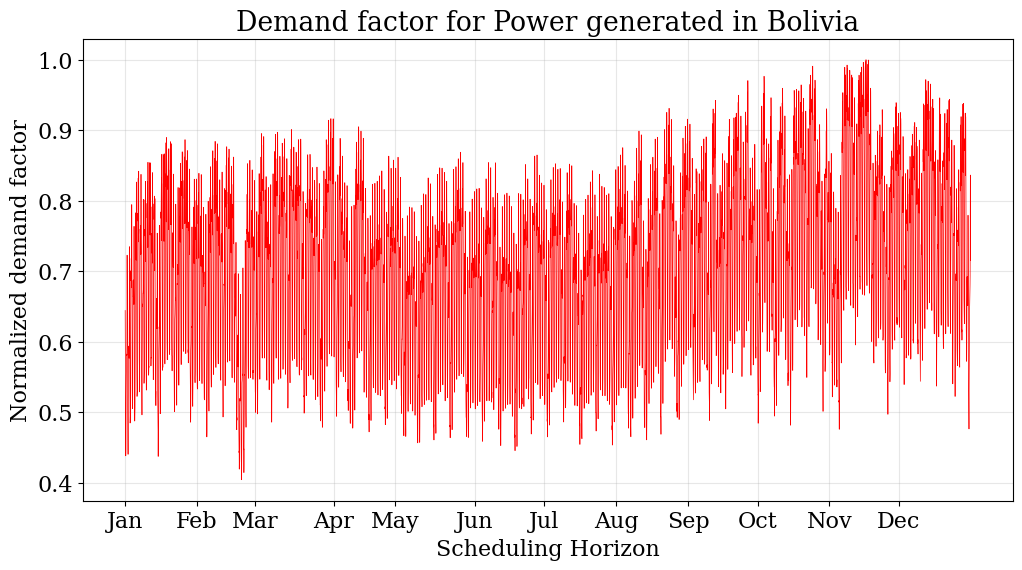

In [24]:
plot_scenario.capacity_factor(scenario=scenario, location= bolivia, process= PV, color= 'orange')
plot_scenario.capacity_factor(scenario=scenario, location= bolivia, process= WF, color= 'blue')
plot_scenario.demand_factor(scenario=scenario, location=bolivia, resource=Power, color='red')

## Formulate MILP

Here we formulate two milps which differ only in their objectives.

For maximizing the discharge of a particular resource, use the objective MAX_DISCHARGE, the objective resource also needs to be specified.

Similarly the discharge can also be minimized using MIN_DISCHARGE. This can be used with a demand for another resource being set. For example, minimizing the discharge of carbon dioxide while meeting a hydrogen demand.

The second MILP, minimized the cost while meeting a varying demand for power

In [25]:
milp_cost = formulate(scenario=scenario, constraints={Constraints.COST, Constraints.INVENTORY, Constraints.PRODUCTION, Constraints.RESOURCE_BALANCE,
                                                     Constraints.DEMAND, Constraints.NETWORK, Constraints.EMISSION}, objective=Objective.COST)


constraint process capex
constraint process fopex
constraint process vopex
constraint process incidental
constraint storage cost
constraint storage cost location
constraint storage cost network
constraint global warming potential process
constraint global warming potential resource
constraint global warming potential resource consumption
constraint global warming potential resource discharge
constraint global warming potential location
constraint global warming potential network
constraint production mode
constraint inventory balance
constraint inventory network
constraint storage facility
constraint production facility
constraint min production facility
constraint min storage facility
constraint demand
objective cost


## Optimize to maximize resource discharge

In [26]:
# results_demand = solve(scenario=scenario, instance=milp_demand,
#                        solver='gurobi', name=f"results_demand", print_solversteps=True)

## Optimize to minimize cost

In [27]:
results_cost = solve(scenario=scenario, instance=milp_cost,
                     solver='gurobi', name=f"res_cost",  print_solversteps=True, saveformat = '.pkl')


Set parameter QCPDual to value 1
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13700, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 24 logical processors, using up to 24 threads

Optimize a model with 280436 rows, 245553 columns and 736468 nonzeros
Model fingerprint: 0xdb8d2f31
Variable types: 245547 continuous, 6 integer (6 binary)
Coefficient statistics:
  Matrix range     [1e-10, 2e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e-10, 1e+04]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 236229 rows and 210101 columns
Presolve time: 0.08s
Presolved: 44207 rows, 35452 columns, 106341 nonzeros
Variable types: 35452 continuous, 0 integer (0 binary)

Root relaxation: objective 3.378319e+09, 7963 iterations, 0.07 seconds (0.26 work units)

    Nodes    |    Current Node

In [735]:
milp_cost.constraint_resource_purchase_varying.pprint()

constraint_resource_purchase_varying : calculates varying amount spent on resource consumption
    Size=8760, Index=locations*resources_varying_price*{0}*{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 

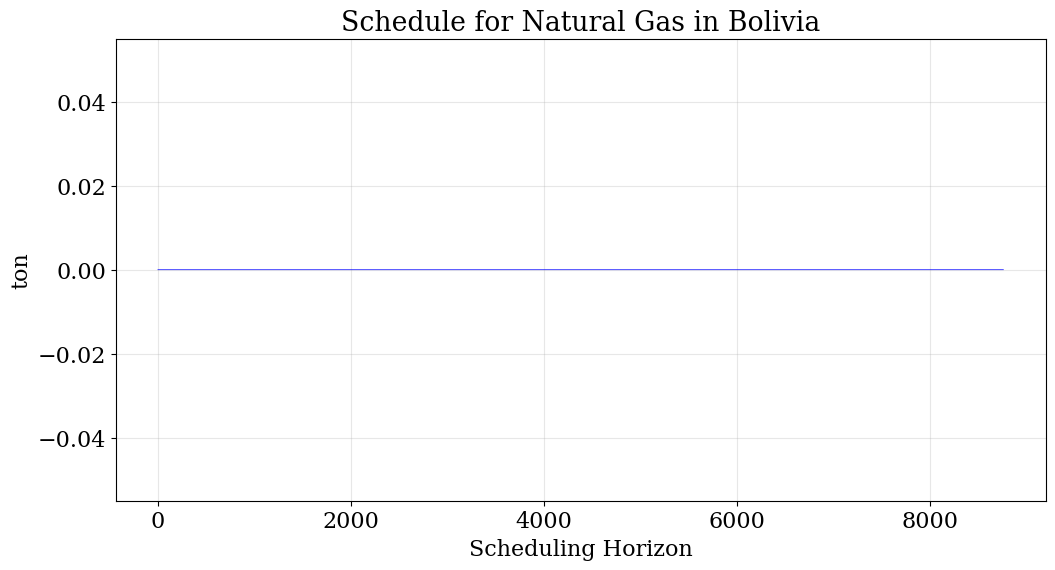

In [736]:
plot_results.schedule(results=results_cost, y_axis='B', component='Natural Gas', location='BO')


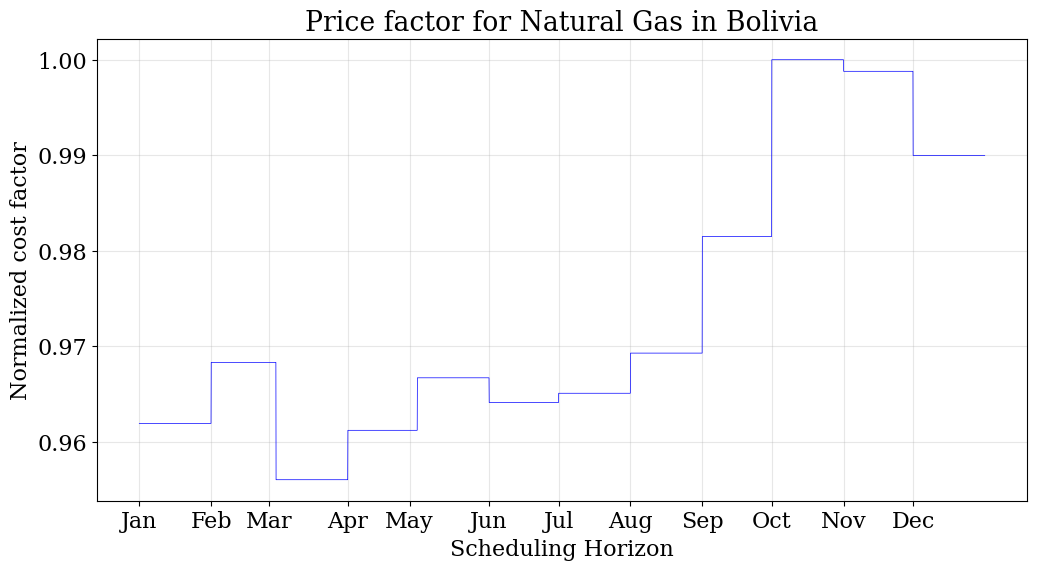

In [737]:
plot_scenario.price_factor(scenario=scenario, resource = NG, location = bolivia)

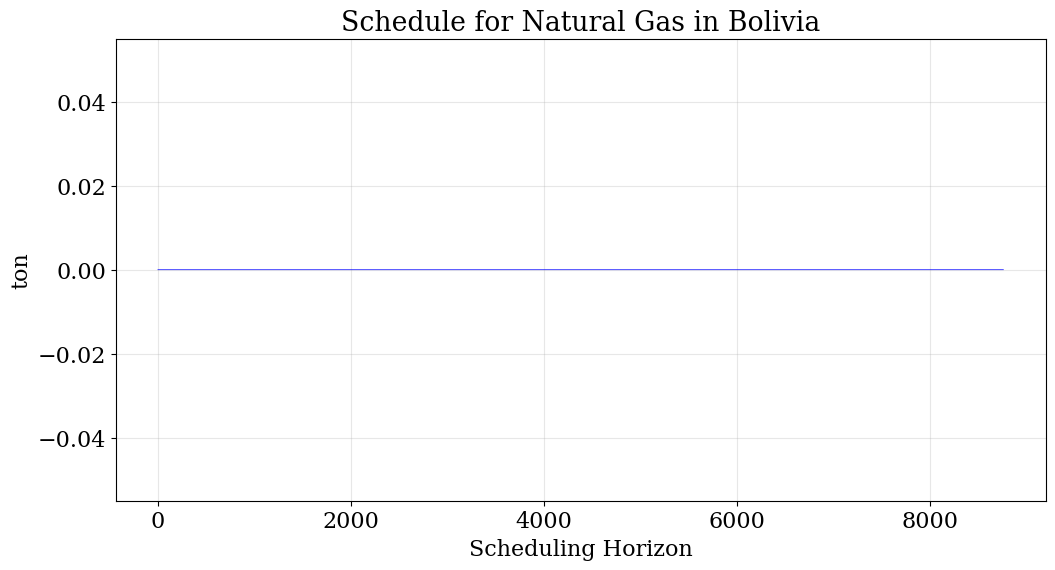

In [738]:
plot_results.schedule(results=results_cost, y_axis='C', component='Natural Gas', location='BO')


In [739]:
results_cost.output['global_warming_potential_network']

{0: 359426667.7264171}

In [740]:
milp_cost.constraint_demand.pprint()

constraint_demand : specific demand for resources
    Size=8760, Index=locations*resources_demand*{0}*{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 20

In [741]:
results_cost.output['Cap_P']

{('BO', 'Biomass production', 0): 926.6410000000001,
 ('BO', 'Hydro production', 0): 734.0,
 ('BO', 'NG production', 0): 0.0,
 ('BO', 'Oil production', 0): 84.0,
 ('BO', 'Solar PV', 0): 0.0,
 ('BO', 'WF', 0): 0.0}

In [742]:
results_cost.output['S_network']

{('CO2_Vent', 0): 358219.726739, ('Power', 0): 10675353.527999999}

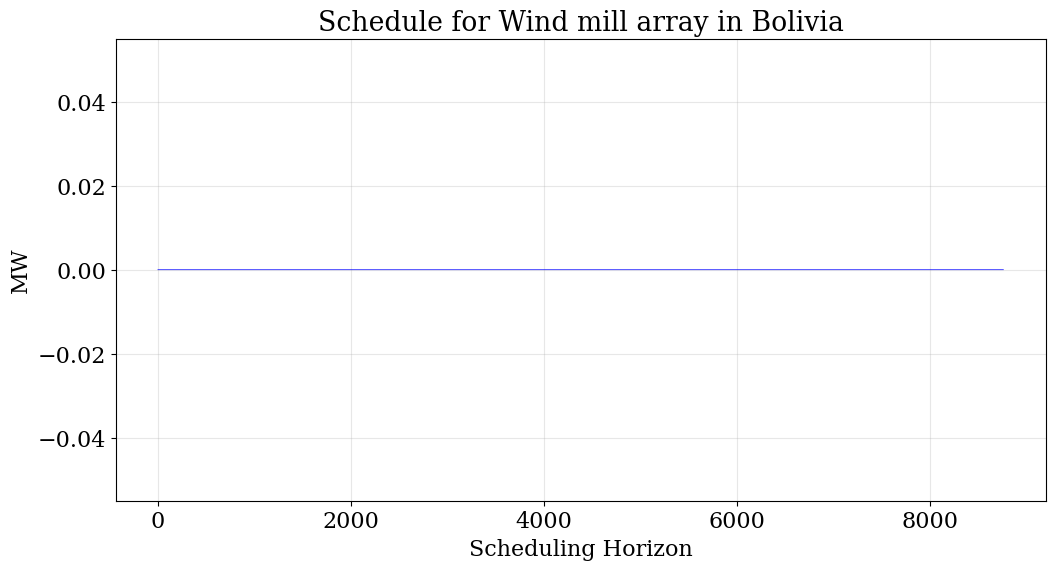

In [743]:
plot_results.schedule(results=results_cost, y_axis='P', component='WF', location='BO')


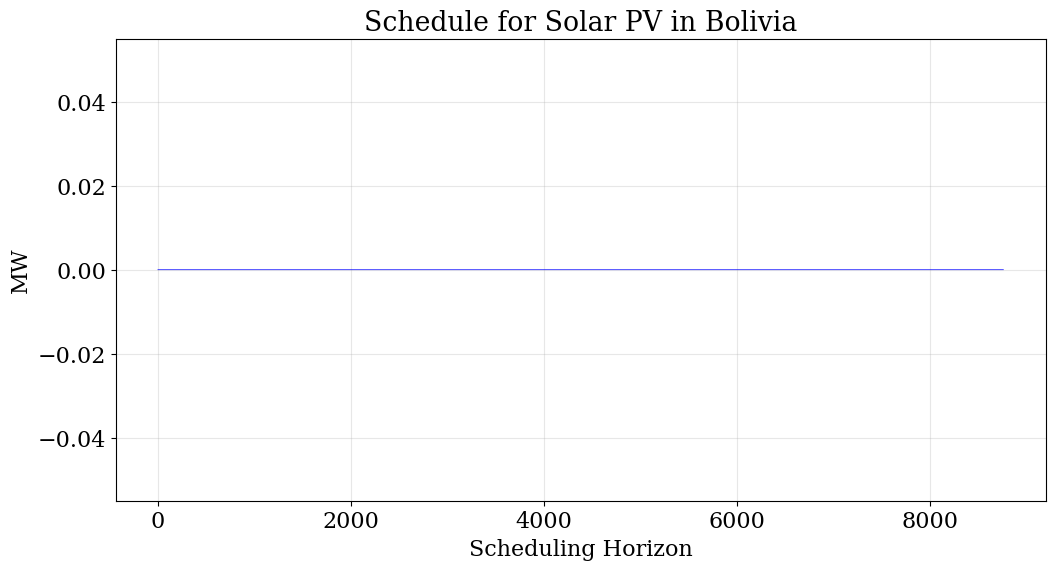

In [744]:
plot_results.schedule(results=results_cost, y_axis='P', component='Solar PV', location='BO')


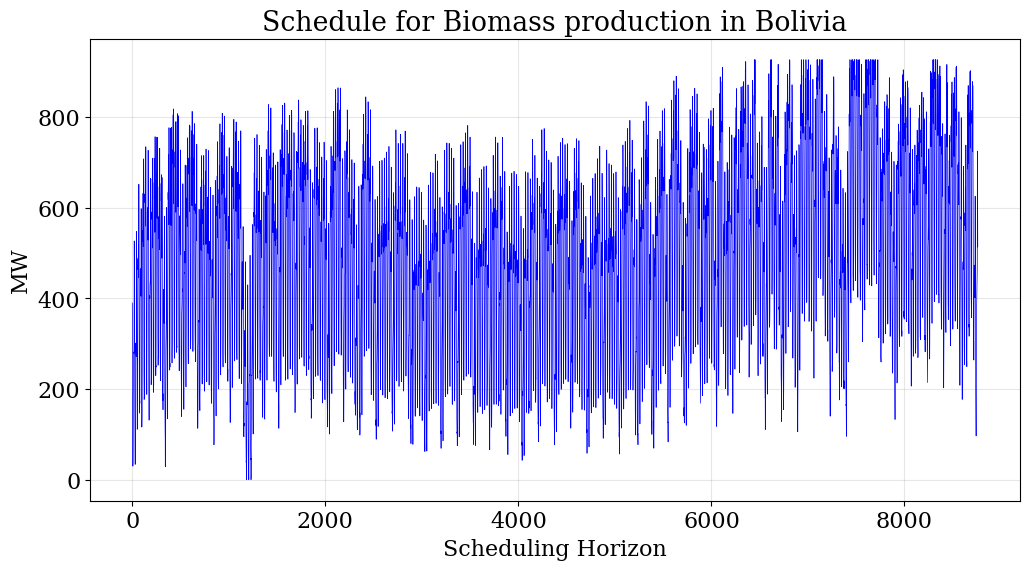

In [745]:
plot_results.schedule(results=results_cost, y_axis='P', component='Biomass production', location='BO')


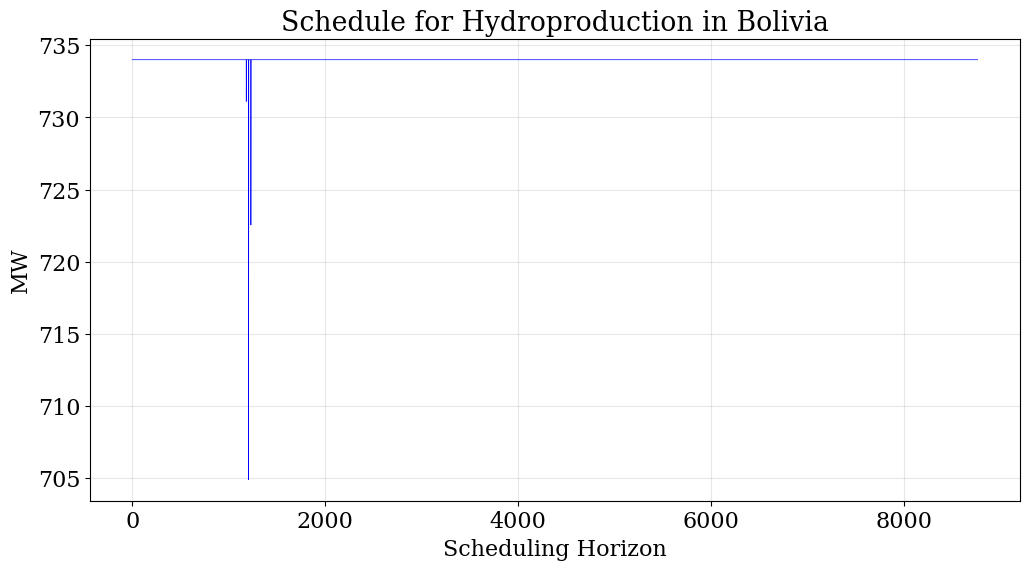

In [746]:
plot_results.schedule(results=results_cost, y_axis='P', component='Hydro production', location='BO')


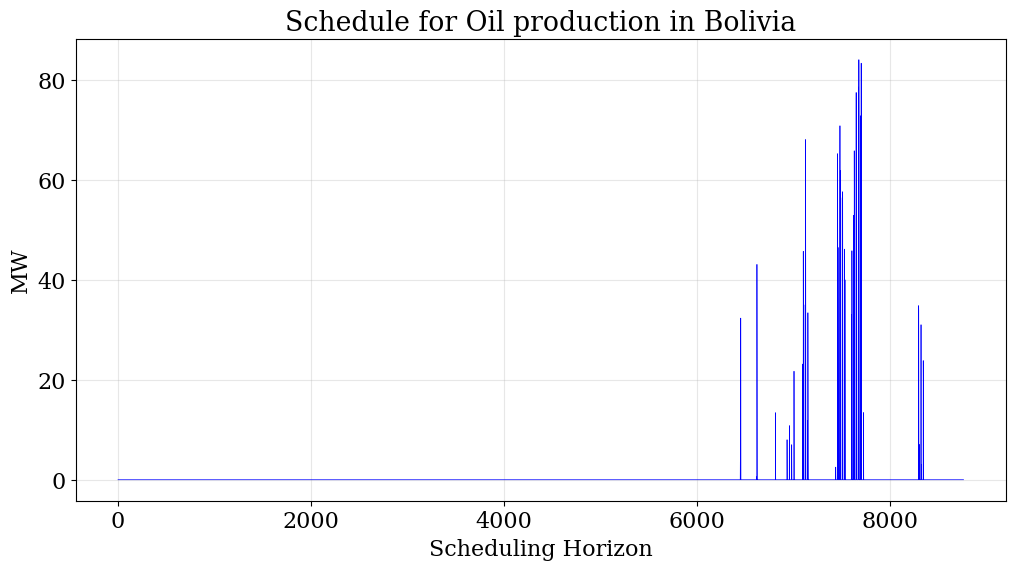

In [747]:
plot_results.schedule(results=results_cost, y_axis='P', component='Oil production', location='BO')


![Inv](plots/inv_liibr.png)

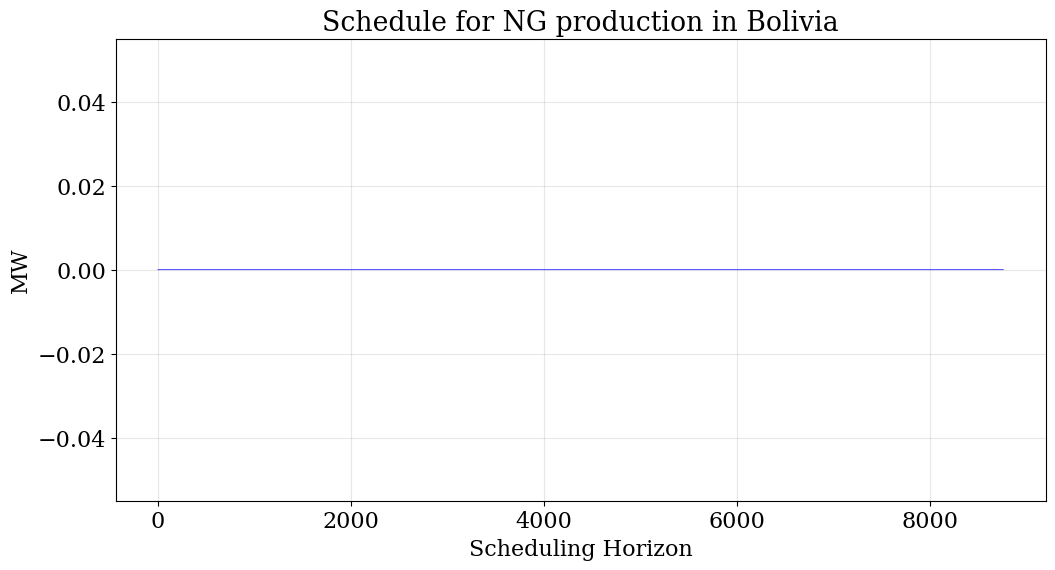

In [748]:
plot_results.schedule(results=results_cost, y_axis='P', component='NG production', location='BO')


([0, 1, 2],
 [Text(0, 0, 'Biomass production'),
  Text(1, 0, 'Hydro production'),
  Text(2, 0, 'Oil production')])

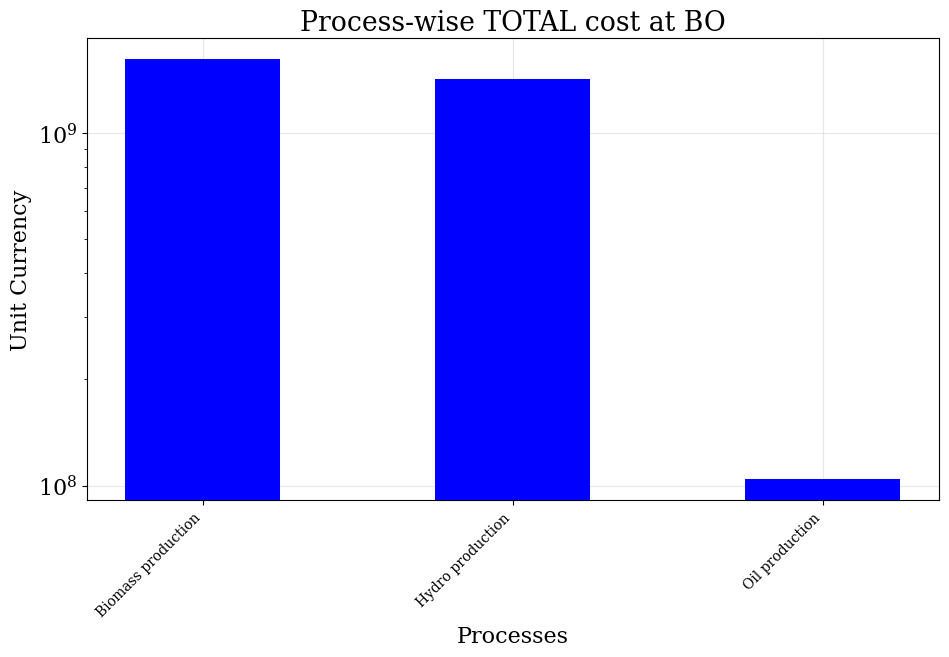

In [749]:
plot_results.cost(results=results_cost, x=CostX.PROCESS_WISE,
                  y=CostY.TOTAL, location='BO', fig_size=(11, 6), )
#plt.rc('xtick', titlesize=8, labelsize=8)
plt.xticks(fontsize=10, rotation=45, ha='right')

In [686]:
milp_gwp = formulate(scenario=scenario, constraints={Constraints.COST, Constraints.INVENTORY, Constraints.PRODUCTION,
                     Constraints.RESOURCE_BALANCE, Constraints.NETWORK, Constraints.DEMAND, Constraints.EMISSION}, objective=Objective.MIN_GWP, demand_sign = 'geq')

constraint process capex
constraint process fopex
constraint process vopex
constraint process incidental
constraint storage cost
constraint storage cost location
constraint storage cost network
constraint global warming potential process
constraint global warming potential resource
constraint global warming potential resource consumption
constraint global warming potential resource discharge
constraint global warming potential location
constraint global warming potential network


constraint production mode
constraint inventory balance
constraint inventory network
constraint storage facility
constraint production facility
constraint min production facility
constraint min storage facility
constraint demand
constraint network cost
objective gwp min


In [504]:
results_gwp = solve(scenario=scenario, instance=milp_gwp,
                     solver='gurobi', name=f"res_gwp", print_solversteps=True, saveformat = '.pkl')

Set parameter QCPDual to value 1
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13700, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 24 logical processors, using up to 24 threads

Optimize a model with 271677 rows, 245553 columns and 718958 nonzeros
Model fingerprint: 0xdbd05db4
Variable types: 245547 continuous, 6 integer (6 binary)
Coefficient statistics:
  Matrix range     [1e-10, 2e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [8e+01, 1e+04]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 254155 rows and 201344 columns
Presolve time: 0.07s
Presolved: 17522 rows, 44209 columns, 61731 nonzeros
Variable types: 44208 continuous, 1 integer (1 binary)

Root relaxation: objective 3.483089e+08, 1 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    

In [340]:
results_cost = load_results('res_cost.pkl')
results_gwp = load_results('res_gwp.pkl')


In [341]:
results_gwp.output['global_warming_potential_network']

{0: 187085907.62196082}

In [342]:
max_reduction = (results_cost.output['global_warming_potential_network'][0] - results_gwp.output['global_warming_potential_network'][0])/results_cost.output['global_warming_potential_network'][0]
max_reduction

0.9744948786439617

(array([-0.06, -0.04, -0.02,  0.  ,  0.02,  0.04,  0.06]),
 [Text(-0.06, 0, '−0.06'),
  Text(-0.039999999999999994, 0, '−0.04'),
  Text(-0.019999999999999997, 0, '−0.02'),
  Text(0.0, 0, '0.00'),
  Text(0.020000000000000004, 0, '0.02'),
  Text(0.04000000000000001, 0, '0.04'),
  Text(0.06, 0, '0.06')])

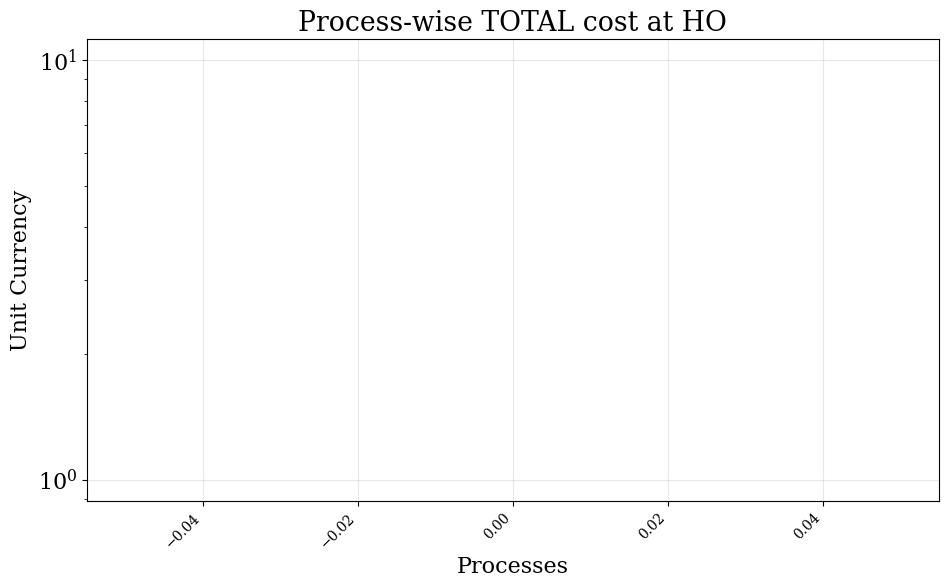

In [343]:
plot_results.cost(results=results_gwp, x=CostX.PROCESS_WISE,
                  y=CostY.TOTAL, location='HO', fig_size=(11, 6), )
#plt.rc('xtick', titlesize=8, labelsize=8)
plt.xticks(fontsize=10, rotation=45, ha='right')

In [344]:
milp_gwp_UAE1 = formulate(scenario=scenario, constraints={Constraints.COST, Constraints.INVENTORY, Constraints.PRODUCTION,
                     Constraints.RESOURCE_BALANCE, Constraints.NETWORK, Constraints.DEMAND, Constraints.EMISSION}, objective=Objective.COST, demand_sign = 'geq')

from energiapy.model.constraints.emission import constraint_global_warming_potential_network_reduction
constraint_global_warming_potential_network_reduction(instance= milp_gwp_UAE1, network_scale_level = 0, gwp_reduction_pct = 10, gwp = results_cost.output['global_warming_potential_network'][0])

constraint process capex
constraint process fopex
constraint process vopex
constraint process incidental
constraint storage cost
constraint storage cost location
constraint storage cost network
constraint global warming potential process
constraint global warming potential resource
constraint global warming potential resource consumption
constraint global warming potential resource discharge
constraint global warming potential location
constraint global warming potential network
constraint production mode
constraint inventory balance
constraint inventory network
constraint storage facility
constraint production facility
constraint min production facility
constraint min storage facility
constraint demand
objective cost
constraint global warming potential network reduction


In [268]:
results_gwp_UAE1 = solve(scenario=scenario, instance=milp_gwp_UAE1,
                     solver='gurobi', name=f"res_gwp_UAE1", print_solversteps=True, saveformat = '.pkl')

Set parameter QCPDual to value 1
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13700, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 24 logical processors, using up to 24 threads

Optimize a model with 280437 rows, 245553 columns and 736469 nonzeros
Model fingerprint: 0xeb5eedf8
Variable types: 245547 continuous, 6 integer (6 binary)
Coefficient statistics:
  Matrix range     [1e-10, 2e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [8e+01, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 227469 rows and 201340 columns
Presolve time: 0.42s
Presolved: 52968 rows, 44213 columns, 176828 nonzeros
Variable types: 44213 continuous, 0 integer (0 binary)
Deterministic concurrent LP optimizer: primal and dual simplex
Showing primal log only...

Concurrent spin time: 0.35s (c

In [269]:
milp_gwp_UAE2 = formulate(scenario=scenario, constraints={Constraints.COST, Constraints.INVENTORY, Constraints.PRODUCTION,
                     Constraints.RESOURCE_BALANCE, Constraints.NETWORK, Constraints.DEMAND, Constraints.EMISSION}, objective=Objective.COST, demand_sign = 'geq')

from energiapy.model.constraints.emission import constraint_global_warming_potential_network_reduction
constraint_global_warming_potential_network_reduction(instance= milp_gwp_UAE2, network_scale_level = 0, gwp_reduction_pct = 20, gwp = results_cost.output['global_warming_potential_network'][0])

constraint process capex
constraint process fopex
constraint process vopex
constraint process incidental
constraint storage cost
constraint storage cost location
constraint storage cost network
constraint global warming potential process
constraint global warming potential resource
constraint global warming potential resource consumption
constraint global warming potential resource discharge
constraint global warming potential location
constraint global warming potential network
constraint production mode
constraint inventory balance
constraint inventory network
constraint storage facility
constraint production facility
constraint min production facility
constraint min storage facility
constraint demand
objective cost
constraint global warming potential network reduction


In [270]:
results_gwp_UAE2 = solve(scenario=scenario, instance=milp_gwp_UAE2,
                     solver='gurobi', name=f"res_gwp_UAE2", print_solversteps=True, saveformat = '.pkl')

Set parameter QCPDual to value 1
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13700, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 24 logical processors, using up to 24 threads

Optimize a model with 280437 rows, 245553 columns and 736469 nonzeros
Model fingerprint: 0xef0e7995
Variable types: 245547 continuous, 6 integer (6 binary)
Coefficient statistics:
  Matrix range     [1e-10, 2e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [8e+01, 6e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 227469 rows and 201340 columns
Presolve time: 0.29s
Presolved: 52968 rows, 44213 columns, 176828 nonzeros
Variable types: 44213 continuous, 0 integer (0 binary)
Deterministic concurrent LP optimizer: primal and dual simplex
Showing primal log only...

Concurrent spin time: 1.69s (c

In [271]:
milp_gwp_UAE3 = formulate(scenario=scenario, constraints={Constraints.COST, Constraints.INVENTORY, Constraints.PRODUCTION,
                     Constraints.RESOURCE_BALANCE, Constraints.NETWORK, Constraints.DEMAND, Constraints.EMISSION}, objective=Objective.COST, demand_sign = 'geq')

from energiapy.model.constraints.emission import constraint_global_warming_potential_network_reduction
constraint_global_warming_potential_network_reduction(instance= milp_gwp_UAE3, network_scale_level = 0, gwp_reduction_pct = 40, gwp = results_cost.output['global_warming_potential_network'][0])

constraint process capex
constraint process fopex
constraint process vopex
constraint process incidental
constraint storage cost
constraint storage cost location
constraint storage cost network
constraint global warming potential process
constraint global warming potential resource
constraint global warming potential resource consumption
constraint global warming potential resource discharge
constraint global warming potential location
constraint global warming potential network
constraint production mode
constraint inventory balance
constraint inventory network
constraint storage facility
constraint production facility
constraint min production facility
constraint min storage facility
constraint demand
objective cost
constraint global warming potential network reduction


In [272]:
results_gwp_UAE3 = solve(scenario=scenario, instance=milp_gwp_UAE3,
                     solver='gurobi', name=f"res_gwp_UAE3", print_solversteps=True, saveformat = '.pkl')

Set parameter QCPDual to value 1
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13700, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 24 logical processors, using up to 24 threads

Optimize a model with 280437 rows, 245553 columns and 736469 nonzeros
Model fingerprint: 0x80b53707
Variable types: 245547 continuous, 6 integer (6 binary)
Coefficient statistics:
  Matrix range     [1e-10, 2e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [8e+01, 4e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 227469 rows and 201340 columns
Presolve time: 0.31s
Presolved: 52968 rows, 44213 columns, 176828 nonzeros
Variable types: 44213 continuous, 0 integer (0 binary)
Deterministic concurrent LP optimizer: primal and dual simplex
Showing primal log only...


Root simplex log...

Iteratio

In [273]:
milp_gwp_UAE4 = formulate(scenario=scenario, constraints={Constraints.COST, Constraints.INVENTORY, Constraints.PRODUCTION,
                     Constraints.RESOURCE_BALANCE, Constraints.NETWORK, Constraints.DEMAND, Constraints.EMISSION}, objective=Objective.COST, demand_sign = 'geq')

from energiapy.model.constraints.emission import constraint_global_warming_potential_network_reduction
constraint_global_warming_potential_network_reduction(instance= milp_gwp_UAE4, network_scale_level = 0, gwp_reduction_pct = 60, gwp = results_cost.output['global_warming_potential_network'][0])

constraint process capex
constraint process fopex
constraint process vopex
constraint process incidental
constraint storage cost
constraint storage cost location
constraint storage cost network
constraint global warming potential process
constraint global warming potential resource
constraint global warming potential resource consumption
constraint global warming potential resource discharge
constraint global warming potential location
constraint global warming potential network
constraint production mode
constraint inventory balance
constraint inventory network
constraint storage facility
constraint production facility
constraint min production facility
constraint min storage facility
constraint demand
objective cost
constraint global warming potential network reduction


In [274]:
results_gwp_UAE4 = solve(scenario=scenario, instance=milp_gwp_UAE4,
                     solver='gurobi', name=f"res_gwp_UAE4", print_solversteps=True, saveformat = '.pkl')

Set parameter QCPDual to value 1
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13700, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 24 logical processors, using up to 24 threads

Optimize a model with 280437 rows, 245553 columns and 736469 nonzeros
Model fingerprint: 0x72875cb3
Variable types: 245547 continuous, 6 integer (6 binary)
Coefficient statistics:
  Matrix range     [1e-10, 2e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [8e+01, 3e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 227469 rows and 201340 columns
Presolve time: 0.27s
Presolved: 52968 rows, 44213 columns, 176828 nonzeros
Variable types: 44213 continuous, 0 integer (0 binary)
Deterministic concurrent LP optimizer: primal and dual simplex
Showing primal log only...


Root simplex log...

Iteratio

In [275]:
milp_gwp_UAE5 = formulate(scenario=scenario, constraints={Constraints.COST, Constraints.INVENTORY, Constraints.PRODUCTION,
                     Constraints.RESOURCE_BALANCE, Constraints.NETWORK, Constraints.DEMAND, Constraints.EMISSION}, objective=Objective.COST, demand_sign = 'geq')

from energiapy.model.constraints.emission import constraint_global_warming_potential_network_reduction
constraint_global_warming_potential_network_reduction(instance= milp_gwp_UAE5, network_scale_level = 0, gwp_reduction_pct = 80, gwp = results_cost.output['global_warming_potential_network'][0])

constraint process capex
constraint process fopex
constraint process vopex
constraint process incidental
constraint storage cost
constraint storage cost location
constraint storage cost network
constraint global warming potential process
constraint global warming potential resource
constraint global warming potential resource consumption
constraint global warming potential resource discharge
constraint global warming potential location
constraint global warming potential network
constraint production mode
constraint inventory balance
constraint inventory network
constraint storage facility
constraint production facility
constraint min production facility
constraint min storage facility
constraint demand
objective cost
constraint global warming potential network reduction


In [276]:
results_gwp_UAE5 = solve(scenario=scenario, instance=milp_gwp_UAE5,
                     solver='gurobi', name=f"res_gwp_UAE5", print_solversteps=True, saveformat = '.pkl')

Set parameter QCPDual to value 1
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13700, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 24 logical processors, using up to 24 threads

Optimize a model with 280437 rows, 245553 columns and 736469 nonzeros
Model fingerprint: 0xe0c5da42
Variable types: 245547 continuous, 6 integer (6 binary)
Coefficient statistics:
  Matrix range     [1e-10, 2e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [8e+01, 1e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 227469 rows and 201340 columns
Presolve time: 0.28s
Presolved: 52968 rows, 44213 columns, 176828 nonzeros
Variable types: 44213 continuous, 0 integer (0 binary)
Deterministic concurrent LP optimizer: primal and dual simplex
Showing primal log only...


Root simplex log...

Iteratio

In [277]:
milp_gwp_max = formulate(scenario=scenario, constraints={Constraints.COST, Constraints.INVENTORY, Constraints.PRODUCTION,
                     Constraints.RESOURCE_BALANCE, Constraints.NETWORK, Constraints.DEMAND, Constraints.EMISSION}, objective=Objective.COST, demand_sign = 'geq')

from energiapy.model.constraints.emission import constraint_global_warming_potential_network_reduction
constraint_global_warming_potential_network_reduction(instance= milp_gwp_max, network_scale_level = 0, gwp_reduction_pct = max_reduction*100, gwp = results_cost.output['global_warming_potential_network'][0])

constraint process capex
constraint process fopex
constraint process vopex
constraint process incidental
constraint storage cost
constraint storage cost location
constraint storage cost network
constraint global warming potential process
constraint global warming potential resource
constraint global warming potential resource consumption
constraint global warming potential resource discharge
constraint global warming potential location
constraint global warming potential network
constraint production mode
constraint inventory balance
constraint inventory network
constraint storage facility
constraint production facility
constraint min production facility
constraint min storage facility
constraint demand
objective cost
constraint global warming potential network reduction


In [278]:
results_gwp_max = solve(scenario=scenario, instance=milp_gwp_max,
                     solver='gurobi', name=f"res_gwp_max", print_solversteps=True, saveformat = '.pkl')

Set parameter QCPDual to value 1
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13700, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 24 logical processors, using up to 24 threads

Optimize a model with 280437 rows, 245553 columns and 736469 nonzeros
Model fingerprint: 0xe309a883
Variable types: 245547 continuous, 6 integer (6 binary)
Coefficient statistics:
  Matrix range     [1e-10, 2e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [8e+01, 2e+08]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 227469 rows and 201340 columns
Presolve time: 0.28s
Presolved: 52968 rows, 44213 columns, 176828 nonzeros
Variable types: 44213 continuous, 0 integer (0 binary)
Deterministic concurrent LP optimizer: primal and dual simplex
Showing primal log only...

Concurrent spin time: 0.00s

S

In [28]:
results_cost = load_results(filename='res_cost.pkl')
results_gwp_UAE1 = load_results(filename='res_gwp_UAE1.pkl')
results_gwp_UAE2 = load_results(filename='res_gwp_UAE2.pkl')
results_gwp_UAE3 = load_results(filename='res_gwp_UAE3.pkl')
results_gwp_UAE4 = load_results(filename='res_gwp_UAE4.pkl')
results_gwp_UAE5 = load_results(filename='res_gwp_UAE5.pkl')
results_gwp_max = load_results(filename='res_gwp_max.pkl')

In [36]:
results_cost.output['Cap_P']

{('BO', 'Biomass production', 0): 926.6410000000001,
 ('BO', 'Hydro production', 0): 734.0,
 ('BO', 'NG production', 0): 0.0,
 ('BO', 'Oil production', 0): 84.0,
 ('BO', 'Solar PV', 0): 0.0,
 ('BO', 'WF', 0): 0.0}

In [281]:
results_gwp_UAE1.output['P_network']

{('Biomass production', 0): 0.0,
 ('Hydro production', 0): 1101190.407404881,
 ('NG production', 0): 9574163.120595114,
 ('Oil production', 0): 0.0,
 ('Solar PV', 0): 0.0,
 ('WF', 0): 0.0}

In [282]:
results_gwp_UAE2.output['P_network']

{('Biomass production', 0): 0.0,
 ('Hydro production', 0): 2202380.8148097964,
 ('NG production', 0): 8472972.713190198,
 ('Oil production', 0): 0.0,
 ('Solar PV', 0): 0.0,
 ('WF', 0): 0.0}

In [283]:
results_gwp_UAE3.output['P_network']

{('Biomass production', 0): 0.0,
 ('Hydro production', 0): 4404761.62961962,
 ('NG production', 0): 6270591.898380287,
 ('Oil production', 0): 0.0,
 ('Solar PV', 0): 0.0,
 ('WF', 0): 0.0}

In [284]:
results_gwp_UAE4.output['P_network']

{('Biomass production', 0): 0.0,
 ('Hydro production', 0): 6607142.444429405,
 ('NG production', 0): 4068211.0835704147,
 ('Oil production', 0): 0.0,
 ('Solar PV', 0): 0.0,
 ('WF', 0): 0.0}

In [285]:
results_gwp_UAE5.output['P_network']

{('Biomass production', 0): 0.0,
 ('Hydro production', 0): 8809523.25923987,
 ('NG production', 0): 1865830.2687602078,
 ('Oil production', 0): 0.0,
 ('Solar PV', 0): 0.0,
 ('WF', 0): 0.0}

In [286]:
results_gwp_max.output['P_network']

{('Biomass production', 0): 0.0,
 ('Hydro production', 0): 6038288.969745325,
 ('NG production', 0): 0.0,
 ('Oil production', 0): 0.0,
 ('Solar PV', 0): 0.0,
 ('WF', 0): 4637064.558254673}

In [287]:
import pandas
import numpy
from energiapy.components.temporal_scale import TemporalScale
from energiapy.components.resource import Resource, VaryingResource
from energiapy.components.process import Process, VaryingProcess
from energiapy.components.material import Material
from energiapy.components.location import Location
from energiapy.components.network import Network
from energiapy.components.scenario import Scenario
from energiapy.components.transport import Transport
from energiapy.model.formulate import formulate, Constraints, Objective
from energiapy.utils.nsrdb_utils import fetch_nsrdb_data
from energiapy.plot import plot_results, plot_scenario
from energiapy.plot.plot_results import CostY, CostX
from energiapy.model.solve import solve
from itertools import product



from energiapy.components.result import Result
import pandas
from itertools import product
from matplotlib import rc
import matplotlib.pyplot as plt
from energiapy.model.solve import solve
from energiapy.plot.plot_results import CostY, CostX
from energiapy.components.location import Location
from energiapy.plot import plot_results, plot_scenario
from energiapy.utils.nsrdb_utils import fetch_nsrdb_data
from energiapy.model.formulate import formulate, Constraints, Objective
from energiapy.model.bounds import CapacityBounds
from energiapy.utils.data_utils import get_data, make_henry_price_df, remove_outliers, load_results
from energiapy.components.transport import Transport
from energiapy.components.scenario import Scenario
from energiapy.components.network import Network
from energiapy.components.location import Location
from energiapy.components.material import Material

from energiapy.conversion.photovoltaic import solar_power_output
from energiapy.conversion.windmill import wind_power_output

from energiapy.utils.data_utils import load_results
from energiapy.plot import plot_results, plot_scenario
from energiapy.plot.plot_results import CostY, CostX

In [288]:
results_list = [results_cost, results_gwp_UAE1, results_gwp_UAE2, results_gwp_UAE3, results_gwp_max]


In [289]:
results_list = [results_cost, results_gwp_UAE1, results_gwp_UAE2, results_gwp_UAE3, results_gwp_UAE4, results_gwp_UAE5, results_gwp_max]


In [290]:
results_cost.output['global_warming_potential_network'][0]


7335229070.677153

In [291]:
cost = [i.output['objective'] for i in results_list]


In [292]:
cost = [i*100/min(cost) for i in cost]


In [293]:
cost


[100.0,
 104.2866593530879,
 108.57331870617591,
 117.1466374123522,
 125.72071192833884,
 135.0766431075672,
 1069.627193175238]

In [294]:
gwp= [i.output['global_warming_potential_network'][0] for i in results_list]


In [295]:
gwp = [i/max(gwp) for i in gwp]


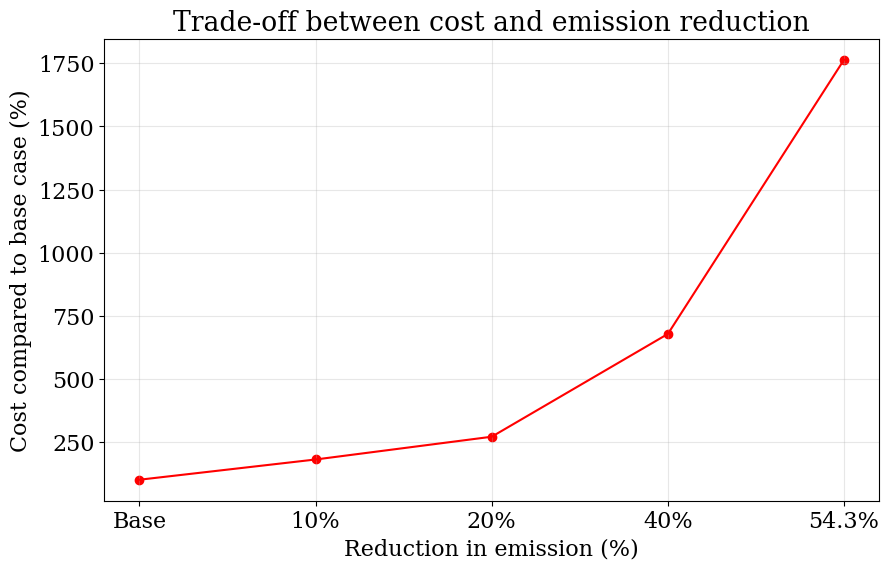

In [231]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc
rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})
fig, ax = plt.subplots(figsize=(10,6))
y_ = [100.0,
 180.1979946567942,
 270.3921740946113,
 677.7387694703685,
 1764.307432289906]
x_ = ['Base', '10%', '20%', '40%', '54.3%']
ax.plot(x_, y_, color='red')
ax.scatter(x_, y_, color='red')
plt.title(f'Trade-off between cost and emission reduction')
plt.ylabel("Cost compared to base case (%)")
plt.xlabel("Reduction in emission (%)")
plt.grid(alpha=0.3)
plt.rcdefaults()

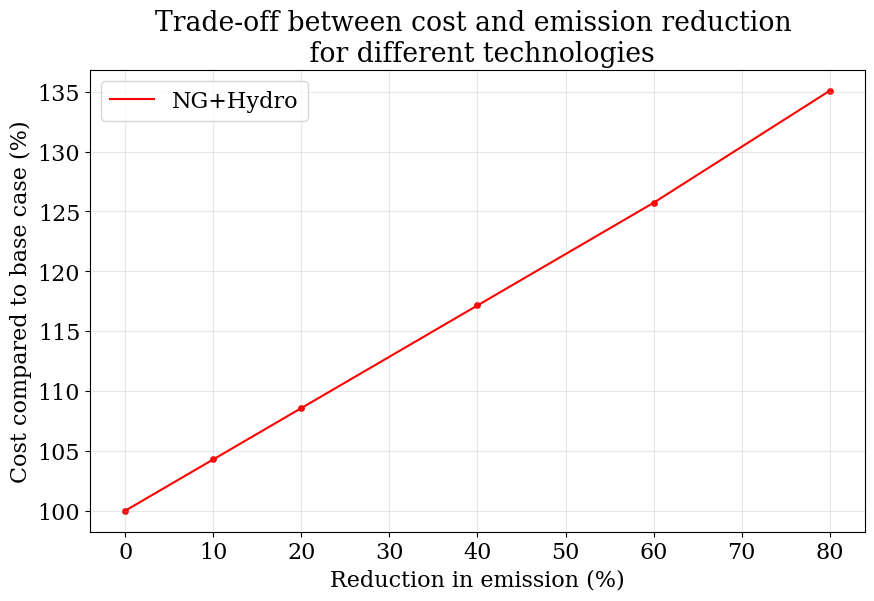

In [236]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})


# Define multiple sets of data for each line
datasets = [
    {
        'y_': [100.0, 104.2866593530879, 108.57331870617591, 117.1466374123522, 125.72071192833884, 135.0766431075672],
        'x_': [0, 10, 20, 40, 60, 80],
        'color': 'red',
        'label': 'NG+Hydro'
    },
]

# Plot all lines on the same graph
fig, ax = plt.subplots(figsize=(10, 6))

for data in datasets:
    ax.plot(data['x_'], data['y_'], color=data['color'], label=data['label'])
    ax.scatter(data['x_'], data['y_'], color=data['color'], s=15)

plt.title('Trade-off between cost and emission reduction \n for different technologies')
# varying $H_2$ price
plt.ylabel('Cost compared to base case (%)')
plt.xlabel('Reduction in emission (%)')
plt.grid(alpha=0.3)
plt.legend()
plt.rcdefaults()
plt.show()



New correct version of the plot

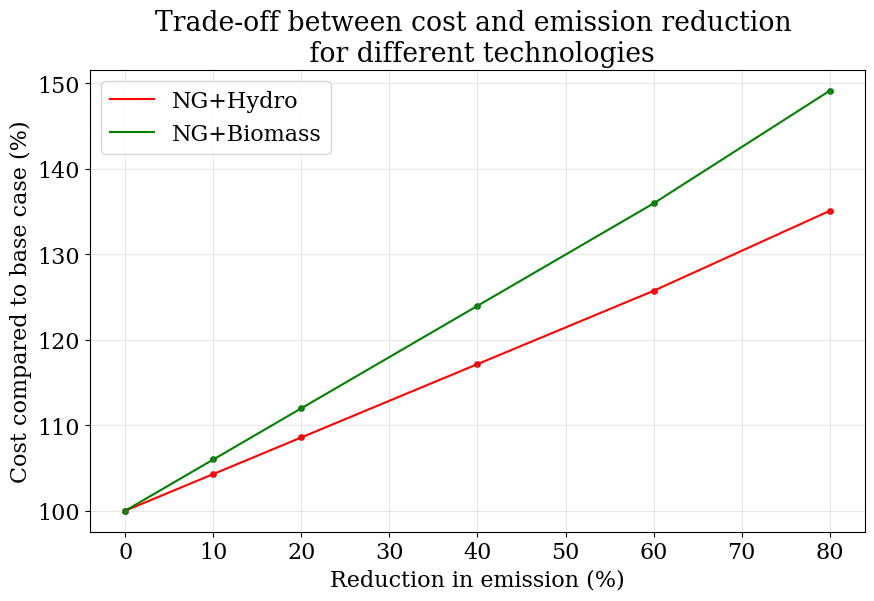

In [235]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})


# Define multiple sets of data for each line
datasets = [
    {
        'y_': [100.0, 104.2866593530879, 108.57331870617591, 117.1466374123522, 125.72071192833884, 135.0766431075672],
        'x_': [0, 10, 20, 40, 60, 80],
        'color': 'red',
        'label': 'NG+Hydro'
    },
    {
        'y_': [100.0, 105.9909582940853, 111.98191658817072, 123.96383317634202, 135.94831353832757, 149.1226050736651],
        'x_': [0, 10, 20, 40, 60, 80],
        'color': 'green',
        'label': 'NG+Biomass'
    },
]

# Plot all lines on the same graph
fig, ax = plt.subplots(figsize=(10, 6))

for data in datasets:
    ax.plot(data['x_'], data['y_'], color=data['color'], label=data['label'])
    ax.scatter(data['x_'], data['y_'], color=data['color'], s=15)

plt.title('Trade-off between cost and emission reduction \n for different technologies')
# varying $H_2$ price
plt.ylabel('Cost compared to base case (%)')
plt.xlabel('Reduction in emission (%)')
plt.grid(alpha=0.3)

plt.legend()
plt.rcdefaults()
plt.show()



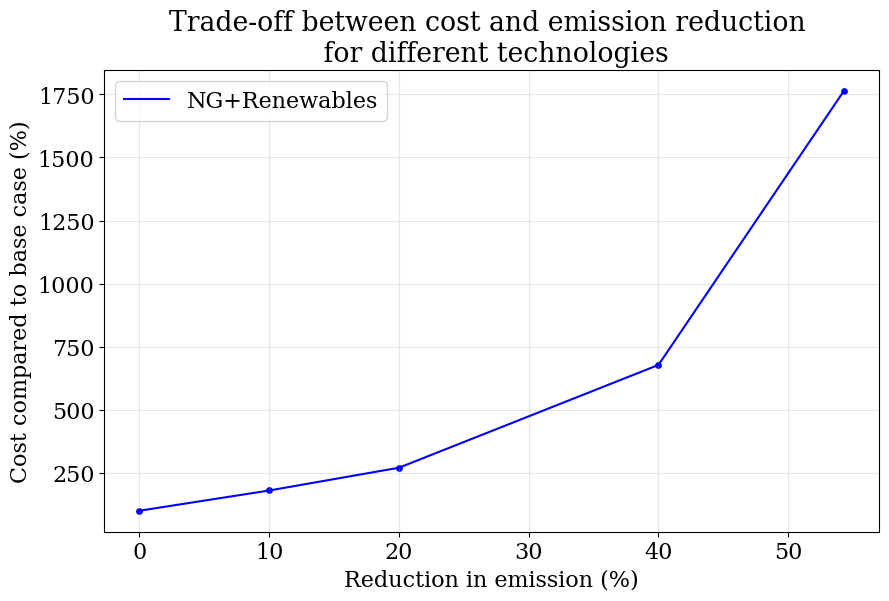

In [234]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})


# Define multiple sets of data for each line
datasets = [

    {   
        'y_': [100.0, 180.1979946567942, 270.3921740946113, 677.7387694703685, 1764.307432289906],
        'x_': [0, 10, 20, 40, 54.3],
        'color': 'blue',
        'label': 'NG+Renewables'  
    },
]

# Plot all lines on the same graph
fig, ax = plt.subplots(figsize=(10, 6))

for data in datasets:
    ax.plot(data['x_'], data['y_'], color=data['color'], label=data['label'])
    ax.scatter(data['x_'], data['y_'], color=data['color'], s=15)

plt.title('Trade-off between cost and emission reduction \n for different technologies')
# varying $H_2$ price
plt.ylabel('Cost compared to base case (%)')
plt.xlabel('Reduction in emission (%)')
plt.grid(alpha=0.3)

plt.legend()
plt.rcdefaults()
plt.show()


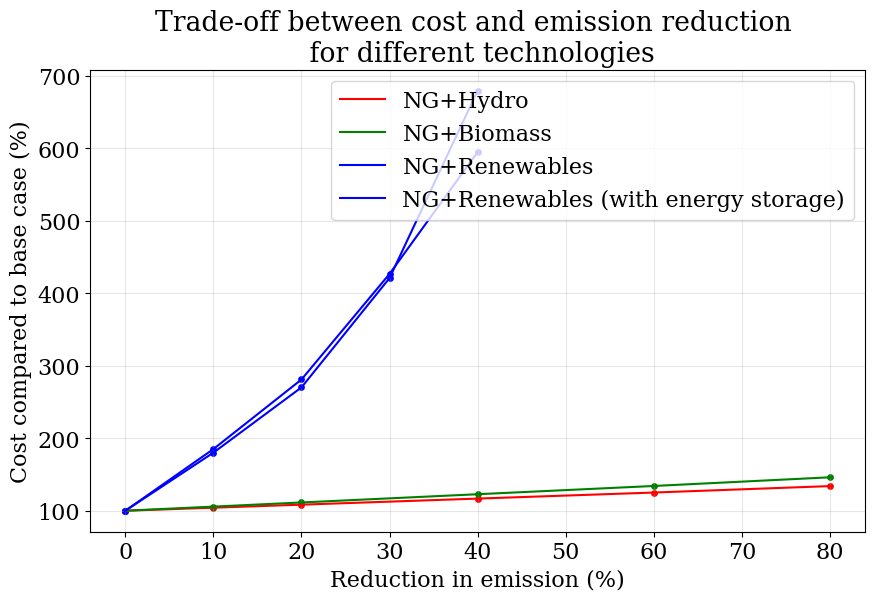

In [155]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})


# Define multiple sets of data for each line
datasets = [
    {
        'y_': [100.0, 104.18060305118854, 108.36120610237714, 116.72241220475433, 125.08386326272293, 133.96862334283767],
        'x_': [0, 10, 20, 40, 60, 80],
        'color': 'red',
        'label': 'NG+Hydro'
    },
    {
        'y_': [100.0, 105.69042223235972, 111.38084446471953, 122.76168892943888, 134.14303534376626, 146.09699176883046],
        'x_': [0, 10, 20, 40, 60, 80],
        'color': 'green',
        'label': 'NG+Biomass'
    },

    {   
        'y_': [100.0, 180.115329168091, 270.15140174149354, 420.98350159351946, 679.3964994234927],
        'x_': [0, 10, 20, 30, 40],
        'color': 'blue',
        'label': 'NG+Renewables'  
    },

    {   
        'y_': [100.0,
 185.0580681672781,
 281.03550561638303,
 426.7432787703186,
 594.7824118811606],
        'x_': [0, 10, 20, 30, 40],
        'color': 'blue',
        'label': 'NG+Renewables (with energy storage)'  
    },
]

# Plot all lines on the same graph
fig, ax = plt.subplots(figsize=(10, 6))

for data in datasets:
    ax.plot(data['x_'], data['y_'], color=data['color'], label=data['label'])
    ax.scatter(data['x_'], data['y_'], color=data['color'], s=15)

plt.title('Trade-off between cost and emission reduction \n for different technologies')
# varying $H_2$ price
plt.ylabel('Cost compared to base case (%)')
plt.xlabel('Reduction in emission (%)')
plt.grid(alpha=0.3)
plt.legend()
plt.rcdefaults()
plt.show()


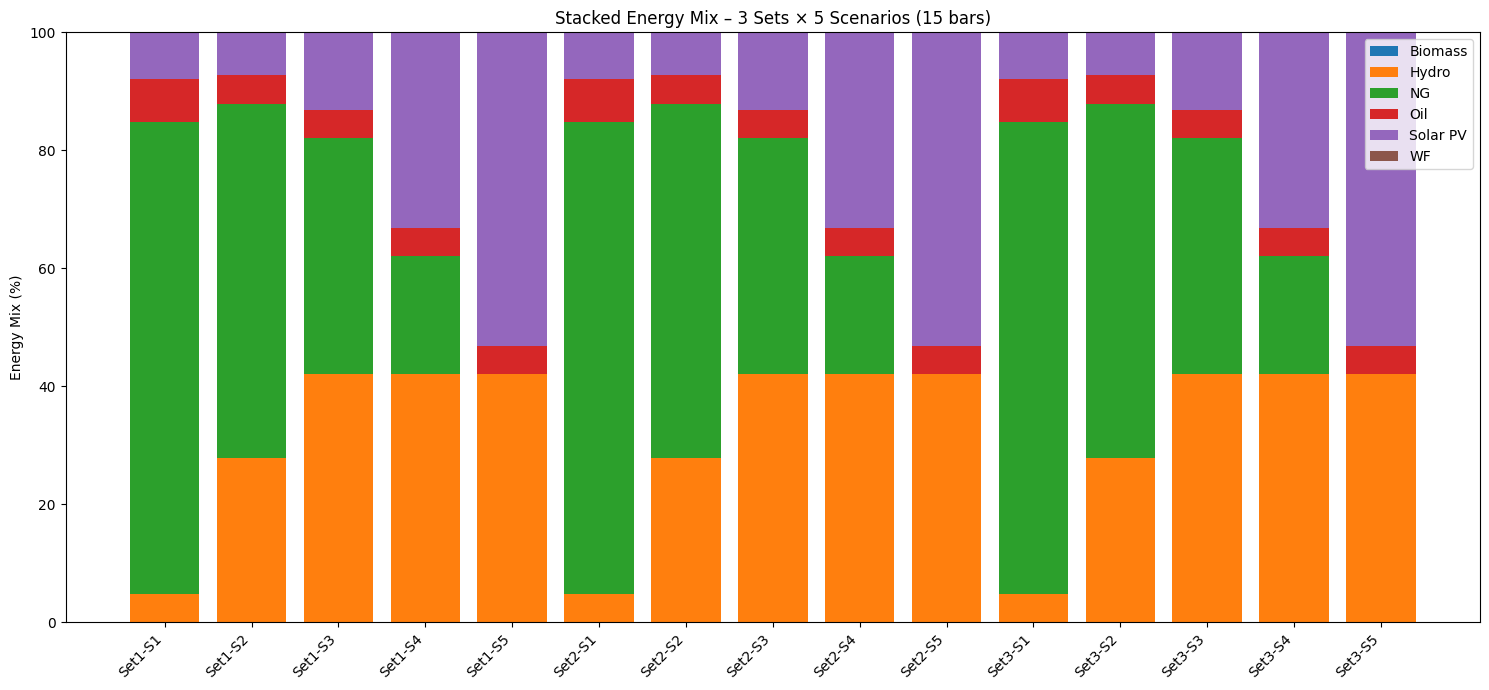

In [750]:
import matplotlib.pyplot as plt
import numpy as np

# ====================================================
# ENTER YOUR THREE SETS OF 5 SCENARIOS
# Format per scenario:
# [Biomass, Hydro, NG, Oil, Solar PV, WF]
# ====================================================

set1_data = {
    "S1": [0, 4.81, 80.00, 7.28, 7.91, 0],
    "S2": [0, 27.91, 60.00, 4.81, 7.28, 0],
    "S3": [0, 42.07, 40.00, 4.81, 13.11, 0],
    "S4": [0, 42.07, 20.00, 4.81, 33.11, 0],
    "S5": [0, 42.07, 0.00, 4.81, 53.11, 0],
}

set2_data = {
    "S1": [0, 4.81, 80.00, 7.28, 7.91, 0],
    "S2": [0, 27.91, 60.00, 4.81, 7.28, 0],
    "S3": [0, 42.07, 40.00, 4.81, 13.11, 0],
    "S4": [0, 42.07, 20.00, 4.81, 33.11, 0],
    "S5": [0, 42.07, 0.00, 4.81, 53.11, 0],
}

set3_data = {
    "S1": [0, 4.81, 80.00, 7.28, 7.91, 0],
    "S2": [0, 27.91, 60.00, 4.81, 7.28, 0],
    "S3": [0, 42.07, 40.00, 4.81, 13.11, 0],
    "S4": [0, 42.07, 20.00, 4.81, 33.11, 0],
    "S5": [0, 42.07, 0.00, 4.81, 53.11, 0],
}

# ====================================================
# Combine the three sets into one sequence of 15 bars
# ====================================================
all_sets = [set1_data, set2_data, set3_data]

labels = []
values = []

for i, dataset in enumerate(all_sets, start=1):
    for s in dataset.keys():
        labels.append(f"Set{i}-{s}")
        values.append(dataset[s])

values = np.array(values).T  # convert to matrix

categories = ["Biomass", "Hydro", "NG", "Oil", "Solar PV", "WF"]

# ====================================================
# Plot stacked bar chart
# ====================================================
plt.figure(figsize=(15, 7))
x = np.arange(len(labels))
bottom = np.zeros(len(labels))

for i, cat in enumerate(categories):
    plt.bar(x, values[i], bottom=bottom, label=cat)
    bottom += values[i]

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Energy Mix (%)")
plt.title("Stacked Energy Mix – 3 Sets × 5 Scenarios (15 bars)")
plt.legend()

plt.tight_layout()
plt.show()


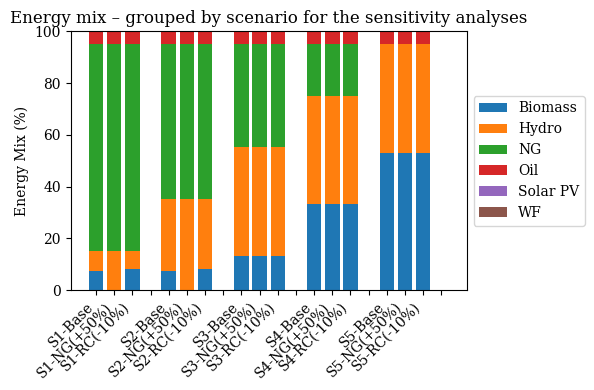

In [772]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 10})


# ====================================================
# ENTER YOUR THREE SETS OF 5 SCENARIOS
# Format per scenario:
# [Biomass, Hydro, NG, Oil, Solar PV, WF]
# ====================================================

set1_data = {
    "S1": [7.28,7.91,80,4.81,0,0],
    "S2": [7.28,27.91,60,4.81,0,0],
    "S3": [13.11,42.07,40,4.81,0,0],
    "S4": [33.11,42.07,20,4.81,0,0],
    "S5": [53.11,42.07,0,4.81,0,0],
}

set2_data = {
    "S1": [0,15.19,80,4.81,0,0],
    "S2": [0,35.19,60,4.81,0,0],
    "S3": [13.11,42.07,40,4.81,0,0],
    "S4": [33.11,42.07,20,4.81,0,0],
    "S5": [53.11,42.07,0,4.81,0,0]
}

set3_data = {
    "S1": [8.27,6.92,80,4.81,0,0],
    "S2": [8.27,26.92,60,4.81,0,0],
    "S3": [13.11,42.07,40,4.81,0,0],
    "S4": [33.11,42.07,20,4.81,0,0],
    "S5": [53.11,42.07,0,4.81,0,0],
}

# ====================================================
# GROUP BY SCENARIO WITH SPACING BETWEEN GROUPS
# ====================================================

scenario_order = ["S1", "S2", "S3", "S4", "S5"]

labels = []
all_data = []

for s in scenario_order:
    # add 3 bars for each scenario
    labels += [f"{s}-Base", f"{s}-NG(+50%)", f"{s}-RC(-10%)"]
    all_data += [set1_data[s], set2_data[s], set3_data[s]]
    
    # add a spacer (zero-height bar)
    labels.append("")          # empty label for spacing
    all_data.append([0, 0, 0, 0, 0, 0])

values = np.array(all_data).T

categories = ["Biomass", "Hydro", "NG", "Oil", "Solar PV", "WF"]

# ====================================================
# PLOT
# ====================================================
plt.figure(figsize=(6, 4))
x = np.arange(len(labels))
bottom = np.zeros(len(labels))

for i, cat in enumerate(categories):
    plt.bar(x, values[i], bottom=bottom, label=cat)
    bottom += values[i]

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Energy Mix (%)")
plt.title("Energy mix – grouped by scenario for the sensitivity analyses")
plt.legend()
plt.legend(loc='center left', bbox_to_anchor=(1,0.5))  # outside center-left

plt.rcdefaults()
plt.tight_layout()
plt.show()


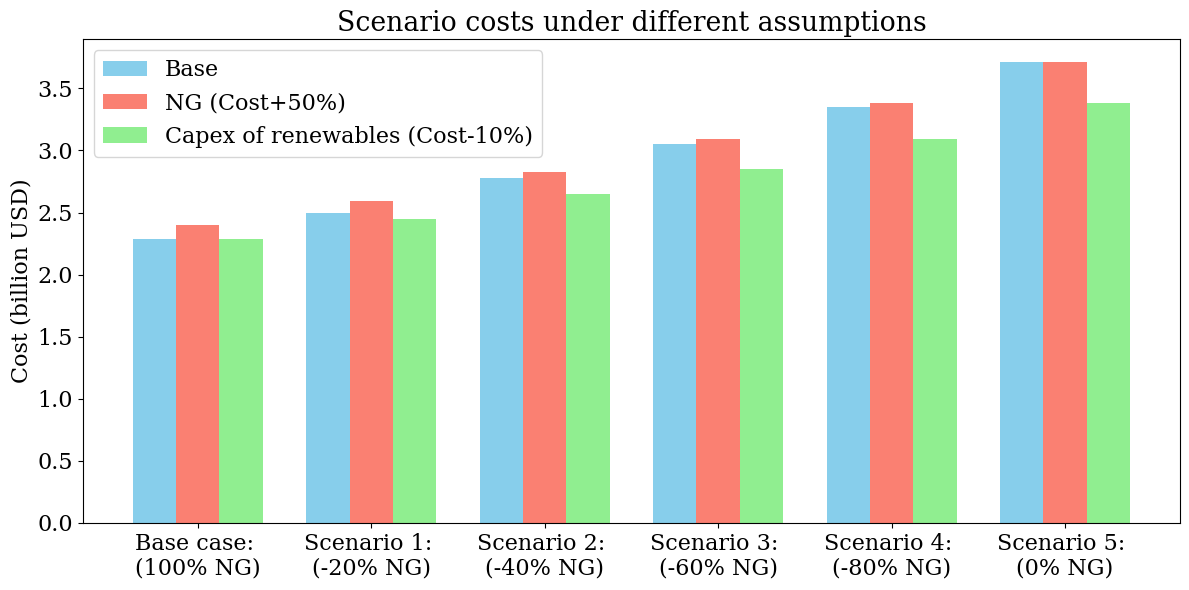

In [794]:
import matplotlib.pyplot as plt
import numpy as np

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})

# Data
scenarios = ["Base case: \n(100% NG)", "Scenario 1: \n(-20% NG)", "Scenario 2: \n(-40% NG)", "Scenario 3: \n(-60% NG)", "Scenario 4: \n(-80% NG)", "Scenario 5: \n(0% NG)"]
cost_base = [2.29, 2.50, 2.78, 3.05, 3.35, 3.71]
cost_ng_exp = [2.40, 2.59, 2.83, 3.09, 3.38, 3.71]
cost_renew = [2.29, 2.45, 2.65, 2.85, 3.09, 3.38]

x = np.arange(len(scenarios))  # x positions for the scenarios
width = 0.25  # width of each bar

# Create figure
plt.figure(figsize=(12,6))

# Plot each cost case
plt.bar(x - width, cost_base, width, label='Base', color='skyblue')
plt.bar(x,       cost_ng_exp, width, label='NG (Cost+50%)', color='salmon')
plt.bar(x + width, cost_renew, width, label='Capex of renewables (Cost-10%)', color='lightgreen')

# Labels and title
plt.xticks(x, scenarios, rotation=0, ha='center')
plt.ylabel("Cost (billion USD)")
plt.title("Scenario costs under different assumptions")
plt.legend()

plt.rcdefaults()
plt.tight_layout()
plt.show()


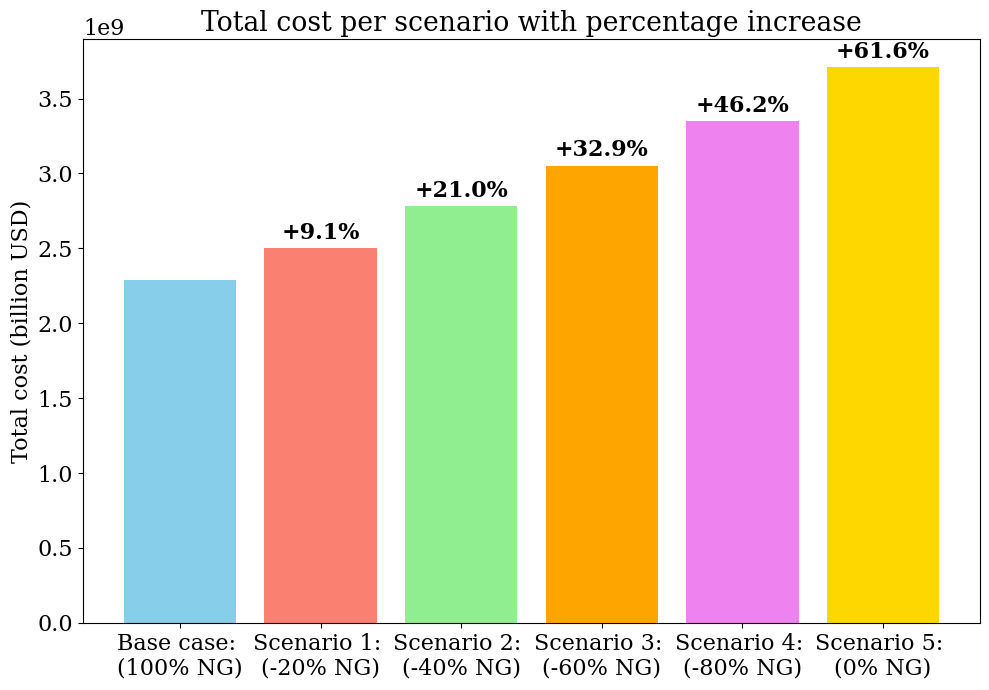

In [814]:
import matplotlib.pyplot as plt
import numpy as np

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})
# Data
scenarios = ["Base case: \n(100% NG)", "Scenario 1: \n(-20% NG)", "Scenario 2: \n(-40% NG)", "Scenario 3: \n(-60% NG)", "Scenario 4: \n(-80% NG)", "Scenario 5: \n(0% NG)"]
total_cost = [2.29e9, 2.50e9, 2.78e9, 3.05e9, 3.35e9, 3.71e9]
percent_increase = [0.0, 9.1, 21.0, 32.9, 46.2, 61.6]

# Assign different colors to each bar
colors = ['skyblue', 'salmon', 'lightgreen', 'orange', 'violet', 'gold']

x = np.arange(len(scenarios))

plt.figure(figsize=(10,7))
bars = plt.bar(x, total_cost, color=colors)

# Add percentage increase on top of each bar
for i, bar in enumerate(bars):
    if i==0:
        continue #skip the first label
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.03e9, f"+{percent_increase[i]}%", 
             ha='center', va='bottom', fontsize=16, fontweight='bold')

# Labels and title
plt.xticks(x, scenarios, rotation=0, ha='center')
plt.ylabel("Total cost (billion USD)")
plt.title("Total cost per scenario with percentage increase")
plt.rcdefaults()
plt.tight_layout()
plt.show()


COST MAX GWP REDUCTION: 1069.6271931822585
{('Hydro production', 0): 6038288.969745313,
 ('NG production', 0): 0.0,
 ('Oil production', 0): 0.0,
 ('Solar PV', 0): 0.0,
 ('WF', 0): 4637064.558254686}